<a href="https://colab.research.google.com/github/kitlapp/Telco_ML/blob/main/Regression_ML_Katerina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn as sk
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler,OneHotEncoder

# Linear regression
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
import statsmodels.api as sm
# Regression metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Regularization - Ridge and Lasso regression (linear regressions)
from sklearn.linear_model import Ridge, RidgeCV, ElasticNet
from sklearn.linear_model import Lasso, LassoCV,ElasticNetCV
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestRegressor
#
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
#
import shap
#
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
#
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
#
import joblib
import requests
import io
#
from sklearn import set_config #this is so that all output from transform keeps the column names
set_config(transform_output="pandas")
#
warnings.simplefilter(action='ignore', category=FutureWarning)

# Set parameters like font sizes for all plots
sns.set_context("paper", rc={"font.size":15,
                             "axes.titlesize":15,
                             "axes.labelsize":15})
plt.rcParams['axes.labelsize']  = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

%matplotlib inline
#
# Set pandas display option to show up to 100 columns when printing a DataFrame
pd.set_option('display.max_columns', 100)


#Load file from Github without .get dummies. To do it after train/test split

In [2]:
#Load file from github public repository
# Read the dataset to a DataFrame
url = "https://github.com/kitlapp/Telco_ML/raw/main/ml_ready_dataset_nodummies.parquet"
df = pd.read_parquet(url, engine="pyarrow")
df.head()

,Is_Male,Is_Senior,Is_Married,Has_Dependents,Tenure,Has_PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,Is_PaperlessBilling,PaymentMethod,Total_Charges,Is_Churned,Avg_Monthly_Charge
0,False,False,True,False,1,False,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,True,Electronic check,29.85,False,29.85
1,True,False,False,False,34,True,No,DSL,Yes,No,Yes,No,No,No,One year,False,Mailed check,1889.50,False,55.57
2,True,False,False,False,2,True,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,True,Mailed check,108.15,True,54.08
3,True,False,False,False,45,False,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,False,Bank transfer (automatic),1840.75,False,40.91
4,False,False,False,False,2,True,No,Fiber optic,No,No,No,No,No,No,Month-to-month,True,Electronic check,151.65,True,75.82


In [3]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 7043
Number of Columns: 20


In [4]:
df.columns.to_list()

['Is_Male',
 'Is_Senior',
 'Is_Married',
 'Has_Dependents',
 'Tenure',
 'Has_PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'Is_PaperlessBilling',
 'PaymentMethod',
 'Total_Charges',
 'Is_Churned',
 'Avg_Monthly_Charge']

**What shall we try to predict with Regression**
Avg_Monthly_Charges : the engineered field which accounts for the total dollars that somebody is paying, regardless of the contract. So it could be more than the contract if they have gone to overage.
**So we do not try to see the contract to be sold, but rathere OPERATIONALLY what the customer spend will be irrespective to contract**

# Drop Correlated Variables
From the correlation analysis we have:  
Avg_monthly charges is correlated as below:  
Correlation with Tenure: 0.249  
Correlation with Total_Charges: 0.651  
Correlation with Monthly_Charges: 0.994  

We drop:

**Monthly_Charges**: correlation is $0.994$, leakage of target in the features.   (Already dropped from EDA. )   
**Total_Charges**:correlation is ($0.651$), not so big, but still avg_total_charges is derived from it.  
**Is_Churned**: this is info not acquired yet. It is in the future

In [5]:
df.head()

,Is_Male,Is_Senior,Is_Married,Has_Dependents,Tenure,Has_PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,Is_PaperlessBilling,PaymentMethod,Total_Charges,Is_Churned,Avg_Monthly_Charge
0,False,False,True,False,1,False,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,True,Electronic check,29.85,False,29.85
1,True,False,False,False,34,True,No,DSL,Yes,No,Yes,No,No,No,One year,False,Mailed check,1889.50,False,55.57
2,True,False,False,False,2,True,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,True,Mailed check,108.15,True,54.08
3,True,False,False,False,45,False,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,False,Bank transfer (automatic),1840.75,False,40.91
4,False,False,False,False,2,True,No,Fiber optic,No,No,No,No,No,No,Month-to-month,True,Electronic check,151.65,True,75.82


In [6]:
df.drop(['Total_Charges', 'Is_Churned'], axis=1, inplace=True)


# Drop Rows for  Tenure = 0

In [7]:
#We also drop Tenure =0 since it constitutes a mistake The other fields have specific values and one would expect the Avg_Monthly_Charges to be of some value
#But it actually has 0 costs. It is noise
df = df[df['Tenure'] > 0].copy()


#First Approach: DataSet with No Additional Features

## Train Test Split

In [8]:
#define X and y
y = df['Avg_Monthly_Charge']
X = df.drop('Avg_Monthly_Charge',axis = 1)
print ("X dimensions: ", X.shape)
print ("y dimensions: ", y.shape)

X dimensions:  (7032, 17)
y dimensions:  (7032,)


In [9]:
# Use the train_test_split() function from sklearn. Use 30% of your data for the test set. Use stratification if needed.
# Set random_state=42 (for reproducibility). Print the dimensionality (shape) of X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.30,
                                                    random_state=42)

print('Shape of X_train and y_train: ', X_train.shape, y_train.shape)
print('Shape of X_test and y_test: ',   X_test.shape,  y_test.shape)

Shape of X_train and y_train:  (4922, 17) (4922,)
Shape of X_test and y_test:  (2110, 17) (2110,)


##ColumnTransformer: OHE and StandartScaler with numerical and categorical features

Since it is very difficult to make sure that ohe will work both for the train and the test without breaking the ML algorithms, since it is done after train-test split,  we will use the ColumnTrnansformer to take care of Scaling for the Numerical and OneHot encoding for the categorical.

In [10]:
#Code provided fromteh lectures
#
# Instead of 6 columns being with "No Internet" flags, we just use the main InternetService category
categorical_features = X_train.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()

cat_steps = [('OHE', OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False))]
pipe_cat = Pipeline(cat_steps)
num_steps = [('scaler', StandardScaler())]
pipe_num = Pipeline(num_steps)

one_pipe = ColumnTransformer(
    transformers=[
        ('numbers', pipe_num, numeric_features),
        ('categories',pipe_cat,categorical_features)
    ])

In [11]:
#fit and transform the train data set. transform the test
X_train_ohe = one_pipe.fit_transform(X_train)
X_test_ohe = one_pipe.transform(X_test)

In [12]:
X_train_ohe.head()

,numbers__Tenure,categories__Is_Male_True,categories__Is_Senior_True,categories__Is_Married_True,categories__Has_Dependents_True,categories__Has_PhoneService_True,categories__MultipleLines_No phone service,categories__MultipleLines_Yes,categories__InternetService_Fiber optic,categories__InternetService_No,categories__OnlineSecurity_No internet service,categories__OnlineSecurity_Yes,categories__OnlineBackup_No internet service,categories__OnlineBackup_Yes,categories__DeviceProtection_No internet service,categories__DeviceProtection_Yes,categories__TechSupport_No internet service,categories__TechSupport_Yes,categories__StreamingTV_No internet service,categories__StreamingTV_Yes,categories__StreamingMovies_No internet service,categories__StreamingMovies_Yes,categories__Contract_One year,categories__Contract_Two year,categories__Is_PaperlessBilling_True,categories__PaymentMethod_Credit card (automatic),categories__PaymentMethod_Electronic check,categories__PaymentMethod_Mailed check
3946,-0.952316,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3394,-0.262207,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1635,-1.195884,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
4088,-1.033505,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1886,1.402172,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [13]:
X_test_ohe.head()

,numbers__Tenure,categories__Is_Male_True,categories__Is_Senior_True,categories__Is_Married_True,categories__Has_Dependents_True,categories__Has_PhoneService_True,categories__MultipleLines_No phone service,categories__MultipleLines_Yes,categories__InternetService_Fiber optic,categories__InternetService_No,categories__OnlineSecurity_No internet service,categories__OnlineSecurity_Yes,categories__OnlineBackup_No internet service,categories__OnlineBackup_Yes,categories__DeviceProtection_No internet service,categories__DeviceProtection_Yes,categories__TechSupport_No internet service,categories__TechSupport_Yes,categories__StreamingTV_No internet service,categories__StreamingTV_Yes,categories__StreamingMovies_No internet service,categories__StreamingMovies_Yes,categories__Contract_One year,categories__Contract_Two year,categories__Is_PaperlessBilling_True,categories__PaymentMethod_Credit card (automatic),categories__PaymentMethod_Electronic check,categories__PaymentMethod_Mailed check
2481,1.158605,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6784,-0.546370,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6125,-0.789938,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3052,0.184334,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4099,-1.074100,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
# We need to clean the column names after Column Transformation to make them more easily readable
X_train_ohe.columns = (X_train_ohe.columns
                       .str.replace('numbers__', '', regex=False)
                       .str.replace('categories__', '', regex=False))

#Same for the X_test_ohe
X_test_ohe.columns = (X_test_ohe.columns
                      .str.replace('numbers__', '', regex=False)
                      .str.replace('categories__', '', regex=False))

# Check the results
X_train_ohe.head()

,Tenure,Is_Male_True,Is_Senior_True,Is_Married_True,Has_Dependents_True,Has_PhoneService_True,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,Is_PaperlessBilling_True,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3946,-0.952316,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3394,-0.262207,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1635,-1.195884,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
4088,-1.033505,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1886,1.402172,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


## Rename Features in Train/Test for better understanding

In [15]:
mapping = {
     'Is_Male_True': 'Is_Male',
     'Is_Senior_True': 'Is_Senior',
     'Is_Married_True': 'Is_Married',
     'Has_Dependents_True': 'Has_Dependents',
     'Has_PhoneService_True': 'Has_PhoneService',
     # One-hot / multi-category features
    'OnlineSecurity_Yes': 'Has_OnlineSecurity_Yes',
    'OnlineSecurity_No internet service': 'Has_OnlineSecurity_NoInternet',
    #'OnlineSecurity_Yes': 'Has_OnlineSecurity_Yes',

    #'OnlineBackup_No': 'Has_OnlineBackup_No',
    'OnlineBackup_No internet service': 'Has_OnlineBackup_NoInternet',
    'OnlineBackup_Yes': 'Has_OnlineBackup_Yes',

    #'DeviceProtection_No': 'Has_DeviceProtection_No',
    'DeviceProtection_No internet service': 'Has_DeviceProtection_NoInternet',
    'DeviceProtection_Yes': 'Has_DeviceProtection_Yes',

    #'TechSupport_No': 'Has_TechSupport_No',
    'TechSupport_No internet service': 'Has_TechSupport_NoInternet',
    'TechSupport_Yes': 'Has_TechSupport_Yes',

    #'StreamingTV_No': 'Has_StreamingTV_No',
    'StreamingTV_No internet service': 'Has_StreamingTV_NoInternet',
    'StreamingTV_Yes': 'Has_StreamingTV_Yes',

    #'StreamingMovies_No': 'Has_StreamingMovies_No',
    'StreamingMovies_No internet service': 'Has_StreamingMovies_NoInternet',
    'StreamingMovies_Yes': 'Has_StreamingMovies_Yes',

    #'MultipleLines_No': 'Has_MultipleLines_No',
    'MultipleLines_No phone service': 'Has_MultipleLines_NoPhone',
    'MultipleLines_Yes': 'Has_MultipleLines_Yes',

    #'InternetService_DSL': 'Is_InternetService_DSL',
    'InternetService_Fiber optic': 'Is_InternetService_FiberOptic',
    'InternetService_No': 'Is_InternetService_None',

    #'Contract_Month-to-month': 'Is_Contract_MonthToMonth',
    'Contract_One year': 'Is_Contract_OneYear',
    'Contract_Two year': 'Is_Contract_TwoYear',

    #'PaymentMethod_Bank transfer (automatic)': 'Is_PaymentMethod_BankTransfer',
    'PaymentMethod_Credit card (automatic)': 'Is_PaymentMethod_CreditCard',
    'PaymentMethod_Electronic check': 'Is_PaymentMethod_ElectronicCheck',
    'PaymentMethod_Mailed check': 'Is_PaymentMethod_MailedCheck'
}
X_train_ohe = X_train_ohe.rename(columns=mapping)
X_test_ohe = X_test_ohe.rename(columns=mapping)

In [16]:
#Sanity Check
X_train_ohe.head()

,Tenure,Is_Male,Is_Senior,Is_Married,Has_Dependents,Has_PhoneService,Has_MultipleLines_NoPhone,Has_MultipleLines_Yes,Is_InternetService_FiberOptic,Is_InternetService_None,Has_OnlineSecurity_NoInternet,Has_OnlineSecurity_Yes,Has_OnlineBackup_NoInternet,Has_OnlineBackup_Yes,Has_DeviceProtection_NoInternet,Has_DeviceProtection_Yes,Has_TechSupport_NoInternet,Has_TechSupport_Yes,Has_StreamingTV_NoInternet,Has_StreamingTV_Yes,Has_StreamingMovies_NoInternet,Has_StreamingMovies_Yes,Is_Contract_OneYear,Is_Contract_TwoYear,Is_PaperlessBilling_True,Is_PaymentMethod_CreditCard,Is_PaymentMethod_ElectronicCheck,Is_PaymentMethod_MailedCheck
3946,-0.952316,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3394,-0.262207,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1635,-1.195884,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
4088,-1.033505,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1886,1.402172,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


##Correlation of OHE Features

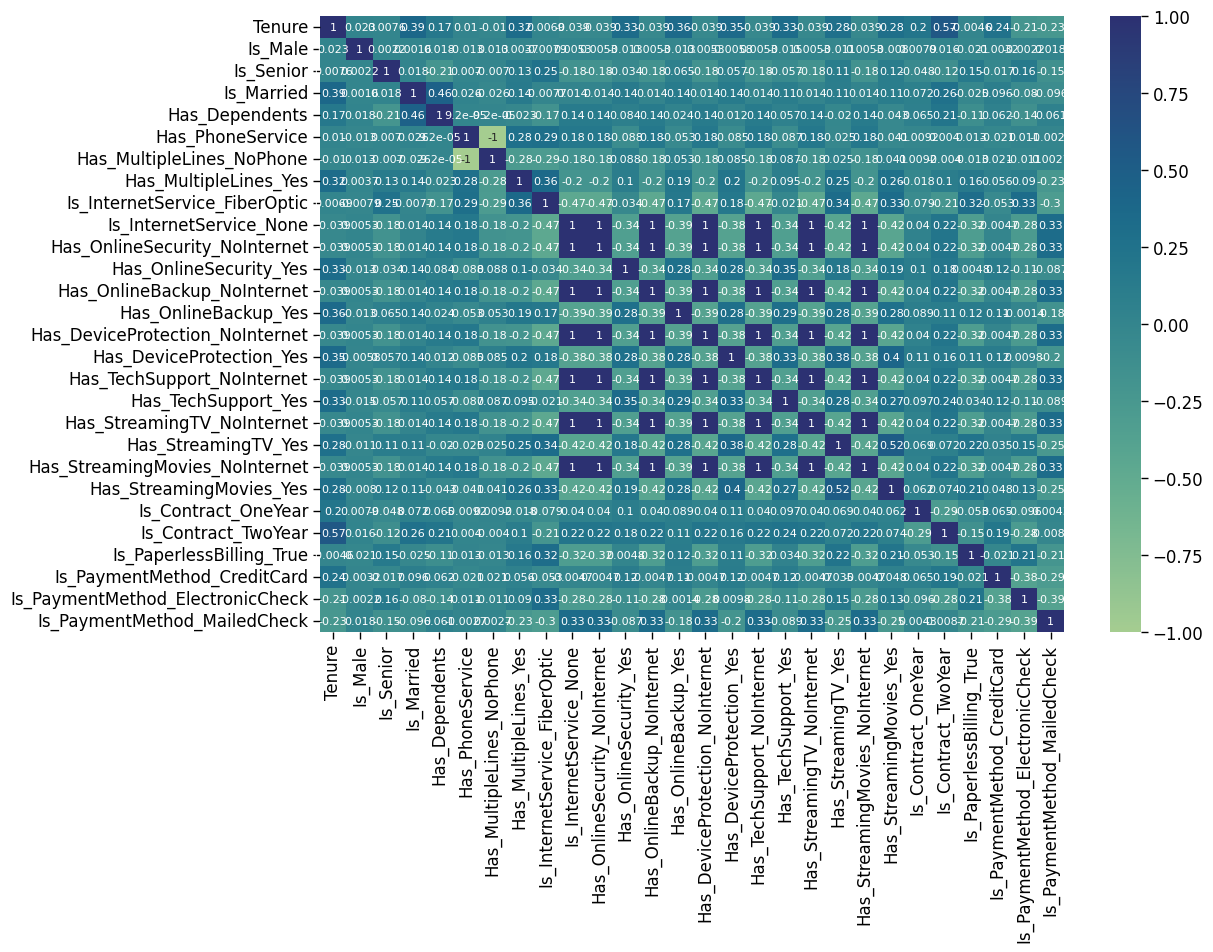

In [17]:
# Calculate the correlation matrix of X_train DataFrame using the .corr() function and
# save it in a variable called 'corr_matrix'. Then pass the corr_matrix to the sns.heatmap() function for plotting.
# Optional: you can use f, ax = plt.subplots(figsize=(12, 8))
# Optional sns.heatmap arguments : annot=True,  annot_kws={'size': 8} and cmap="Spectral_r"

corr_matrix = X_train_ohe.corr()

f, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,
            annot_kws={'size': 8},
            cmap="crest");

We need to drop all the "No Internet" columns as they are highly correlated with the Is_InternetService_Nonw. If the model knows the person has "No Internet Service" via the InternetService_None column, it doesn't need 6 more columns telling it the same thing for every sub-feature.

This is very important for Regression Models and Multicollinearity

## Reduce Dimensionality due to extreme correlation with NoInternet and NoPhone descrition


In [18]:
#Find the columns to exclude with names "NoIntenet" or "NoPhone" from the list
# Filter the list
alllist = X_train_ohe.columns.to_list()
redundant_terms = ["NoInternet", "NoPhone"]
toclean_list = [item for item in alllist if any(term in item for term in redundant_terms)]
print(toclean_list)


['Has_MultipleLines_NoPhone', 'Has_OnlineSecurity_NoInternet', 'Has_OnlineBackup_NoInternet', 'Has_DeviceProtection_NoInternet', 'Has_TechSupport_NoInternet', 'Has_StreamingTV_NoInternet', 'Has_StreamingMovies_NoInternet']


In [19]:
X_train_ohe = X_train_ohe.drop(columns=toclean_list)
X_test_ohe = X_test_ohe.drop(columns=toclean_list)

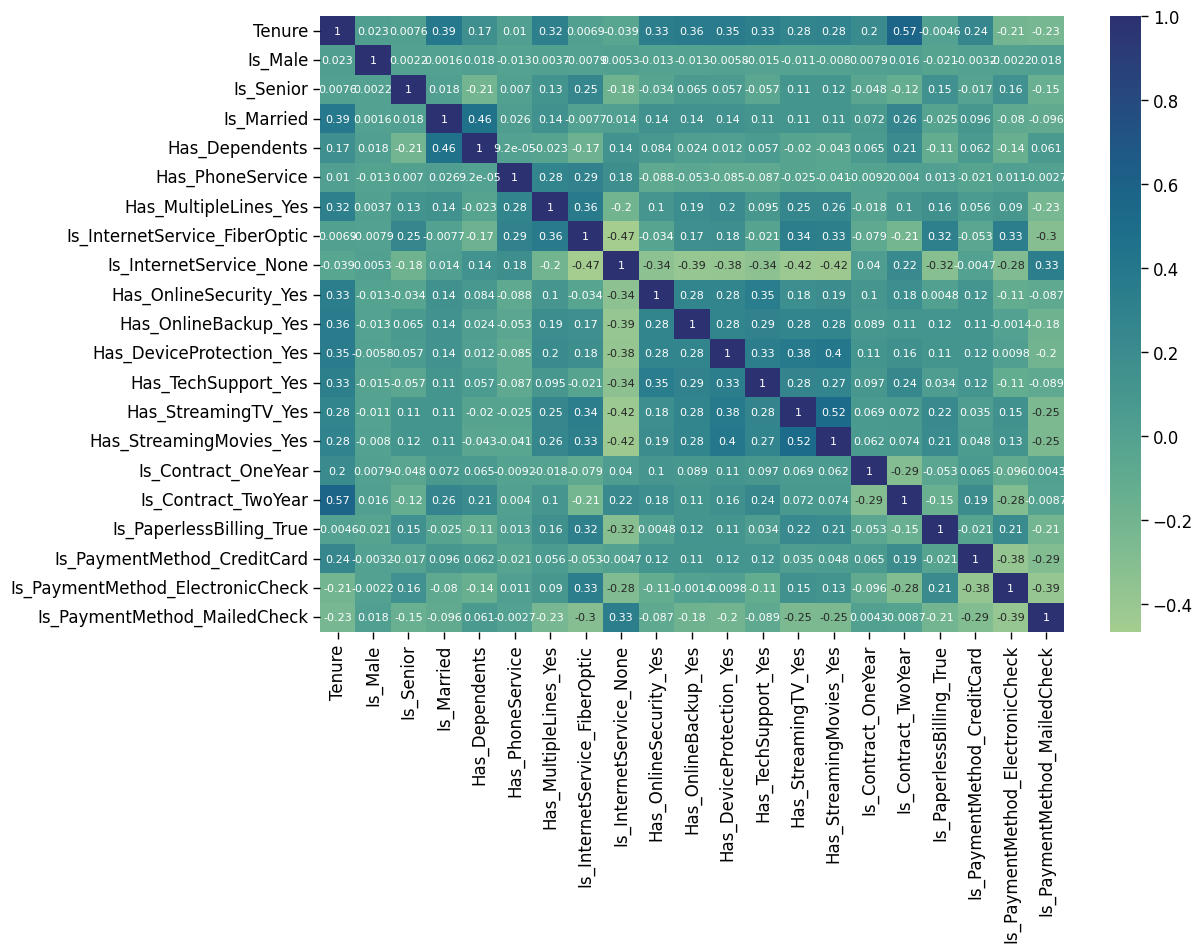

In [20]:
corr_matrix = X_train_ohe.corr()

f, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,
            annot_kws={'size': 8},
            cmap="crest");

In [21]:
X_train_ohe.shape


(4922, 21)

The dataset seems clean now, ready for regression.

# Baseline Simple Models to check behavior

In [22]:
X_train = X_train_ohe.copy()
X_test = X_test_ohe.copy()

## Initialize a DataFrame to hold Regression results

In [23]:
# Create an empty DataFrame named 'regr_results' to store and compare evaluation results from the various regressors
regr_results = pd.DataFrame([])

##Running Various Models

In [24]:
#Linear Regression-------------------------------------------------------------

linear_regr = LinearRegression()
linear_regr.fit(X_train, y_train)
y_pred = linear_regr.predict(X_test)
#
regr_results = pd.concat([regr_results, pd.json_normalize({'Model': 'Linear Regression',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5)})])

# Ridge Regression------------------------------------------------------------
ridgeCV_model = RidgeCV(alphas=np.logspace(-6, 6, 13), scoring='r2', cv=10)
ridgeCV_model.fit(X_train, y_train)
optimal_alpha = ridgeCV_model.alpha_
#
ridge_regr = Ridge(alpha = optimal_alpha)
ridge_regr.fit(X_train, y_train)
y_pred = ridge_regr.predict(X_test)
#
regr_results = pd.concat([regr_results, pd.json_normalize({'Model': 'Ridge',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5),
                                                           'Parameter': round(optimal_alpha,5)})])
#Lasso Regression--------------------------------------------------------------
lassoCV_model = LassoCV(alphas=np.logspace(-6, 6, 13), cv=10, random_state=0)
lassoCV_model.fit(X_train, y_train)
optimal_alpha = lassoCV_model.alpha_
#
lasso_regr = Lasso(alpha = optimal_alpha)
lasso_regr.fit(X_train, y_train)
y_pred = lasso_regr.predict(X_test)
regr_results = pd.concat([regr_results, pd.json_normalize({'Model': 'Lasso',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5),
                                                           'Parameter': round(optimal_alpha,5)})])
#RandomForest Regression ------------------------------------------------------
rf  = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

regr_results = pd.concat([regr_results, pd.json_normalize({'Model': 'RandomForest',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5)})])
# KNN Regression ------------------------------------------------------------
knn = KNeighborsRegressor(n_neighbors=5) # 5 is the standard starting point
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

regr_results = pd.concat([regr_results, pd.json_normalize({
                                                           'Model': 'KNN',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5)})])

# SVM Regression Linear ------------------------------------------------------------
svr = SVR(kernel='linear', C=1.0) # Linear kernel matches Lineear Regression
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)

regr_results = pd.concat([regr_results, pd.json_normalize({'Model': 'SVR Linear',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5)})])
# SVM Regression RBF ------------------------------------------------------------
svr = SVR() # Non Linear Kernel
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)

regr_results = pd.concat([regr_results, pd.json_normalize({'Model': 'SVR NonLinear',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5)})])

# XGBoost Regression ---------------------------------------------------------
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

regr_results = pd.concat([regr_results, pd.json_normalize({'Model': 'XGRegressor',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5)})])


In [25]:
regr_results.fillna('--').sort_values(by='r2', ascending=False)

,Model,r2,MAE,Parameter
0,SVR Linear,0.99081,2.02009,--
0,Linear Regression,0.99080,2.01877,--
0,Lasso,0.99080,2.01854,0.01
0,Ridge,0.99080,2.01878,0.1
0,XGRegressor,0.99012,2.12179,--
0,RandomForest,0.98807,2.33721,--
0,SVR NonLinear,0.98790,2.41806,--
0,KNN,0.95690,4.35389,--


In [26]:
regr_results.fillna('--').sort_values(by='MAE', ascending=False)

,Model,r2,MAE,Parameter
0,KNN,0.95690,4.35389,--
0,SVR NonLinear,0.98790,2.41806,--
0,RandomForest,0.98807,2.33721,--
0,XGRegressor,0.99012,2.12179,--
0,SVR Linear,0.99081,2.02009,--
0,Ridge,0.99080,2.01878,0.1
0,Linear Regression,0.99080,2.01877,--
0,Lasso,0.99080,2.01854,0.01


MAE is a metric that shows the proximity to the predicted value. Taking under consideration that the mean is close to 65 and the median close to 70, then the MAE of 2.5 is quite good.
The R^2 is a measure of how much of the variablity in y is determined by the X values . So all models have very high values

We are going to see how algorithms behave for
**XGBoost and Ridge** for R^2 and
**SVR and Lasso** for MAE

**Tree-based "Feature Importance":** Shows how much a feature was used to split the data (e.g., "Tenure is 0.45 important"). It's always a positive number.

**Lasso "Coefficients":** show the actual weight of the feature (e.g., "Fiber Optic is +42.0").

## Coefficients for Lasso, Ridge  ,Linear SVR

### Lasso Coefficients

r2 score (coefficient of determination): 0.991
MAE : 2.019
alpha: ",optimal_alpha
Model coefficients: [-1.44407696e-02  0.00000000e+00 -2.98306980e-02 -0.00000000e+00
 -0.00000000e+00  1.99707870e+01  5.07946589e+00  2.48547842e+01
 -2.49661875e+01  5.06589371e+00  4.87180560e+00  4.96857787e+00
  5.11513766e+00  9.70253877e+00  1.02475496e+01 -0.00000000e+00
 -0.00000000e+00 -1.54133221e-02 -0.00000000e+00  4.09429915e-03
  0.00000000e+00]


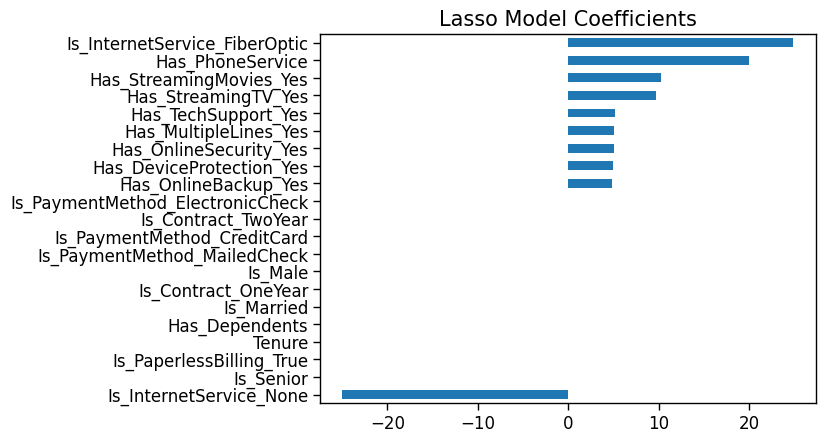

In [27]:
#Lasso Regression--------------------------------------------------------------
lassoCV_model = LassoCV(alphas=np.logspace(-6, 6, 13), cv=10, random_state=0)
lassoCV_model.fit(X_train, y_train)
optimal_alpha = lassoCV_model.alpha_
#
lasso_regr = Lasso(alpha = optimal_alpha)
lasso_regr.fit(X_train, y_train)
y_pred = lasso_regr.predict(X_test)

print('r2 score (coefficient of determination): '+str(round(r2_score(y_test, y_pred),3)))
print('MAE : ' +str(round(mean_absolute_error(y_test, y_pred),3)))
print('alpha: ",optimal_alpha')
#
print('Model coefficients:', lasso_regr.coef_)
#extract the coefficients
coef_lasso = pd.DataFrame({"var": X_train.columns,
                           "coef":lasso_regr.coef_})

coef = pd.Series(lasso_regr.coef_, X_train.columns).sort_values()
coef.plot(kind='barh', title='Lasso Model Coefficients')
plt.show()


### Ridge Coefficients

r2 score (coefficient of determination): 0.991
MAE : 2.019
alpha: ",optimal_alpha
Model coefficients: [-2.73144138e-02  4.98366109e-03 -1.17363279e-01 -2.50279471e-02
  2.24144699e-03  2.00923346e+01  5.10651580e+00  2.48523703e+01
 -2.49634205e+01  5.11019632e+00  4.91166672e+00  5.00547446e+00
  5.15283635e+00  9.72740858e+00  1.02723348e+01 -5.11518108e-02
 -6.41812734e-02 -8.60731518e-02 -7.90545827e-03  5.51223891e-02
  3.54968584e-02]


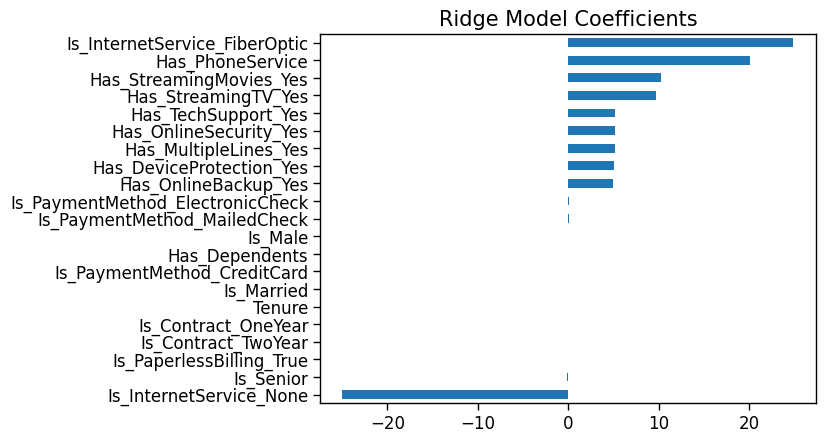

In [28]:
#Ridge Regression--------------------------------------------------------------
ridgeCV_model = RidgeCV(alphas=np.logspace(-6, 6, 13), scoring='r2', cv=10)
ridgeCV_model.fit(X_train, y_train)
optimal_alpha = ridgeCV_model.alpha_
#
ridge_regr = Ridge(alpha = optimal_alpha)
ridge_regr.fit(X_train, y_train)
y_pred = ridge_regr.predict(X_test)

print('r2 score (coefficient of determination): '+str(round(r2_score(y_test, y_pred),3)))
print('MAE : ' +str(round(mean_absolute_error(y_test, y_pred),3)))
print('alpha: ",optimal_alpha')
#
print('Model coefficients:', ridge_regr.coef_)
#extract the coefficients
coef_ridge = pd.DataFrame({"var": X_train.columns,
                           "coef":ridge_regr.coef_})

coef_ridge = pd.Series(ridge_regr.coef_, X_train.columns).sort_values()
coef_ridge.plot(kind='barh', title='Ridge Model Coefficients')
plt.show()


In [29]:
# Optional: create a new DataFrame named 'comparison' where you can combine/compare the actual and predicted values
# Create a new column 'y_actual' and set its values to the ones contained in y_test
# and another new column 'y_predicted' and set its values to the ones in y_pred
# Preview its results

comparison = pd.DataFrame([])
comparison['y_actual'] = y_test
comparison['y_predicted'] = y_pred
comparison.head()

,y_actual,y_predicted
2481,24.62,24.907249
6784,24.52,25.155408
6125,104.54,99.869047
3052,54.89,55.138446
4099,26.91,30.044589


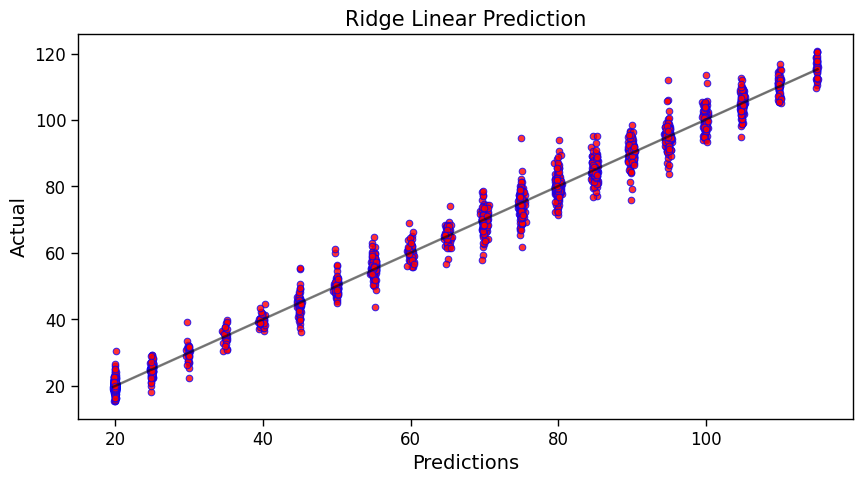

In [30]:
# Visualising the results in a regplot between y_pred and y_test.
# Pass as additional arguments
# scatter_kws={'color':'red','edgecolor':'blue', 'linewidths':0.7}
# and line_kws={'color':'black','alpha':0.5}

plt.figure(figsize=(10,5))
sns.regplot(x= y_pred, y = y_test,
            scatter_kws={'color':'red',
                         'edgecolor':'blue',
                         'linewidths':0.7},
            line_kws={'color':'black','alpha':0.5}
           )
plt.xlabel('Predictions')
plt.ylabel('Actual')
plt.title("Ridge Linear Prediction")
plt.show()

### SVR Coefficients


Model coefficients: [[-1.01276278e-01 -1.88161230e-02  1.82369874e-02 -3.31597084e-02
  -7.94958628e-03  1.98899044e+01  5.16567562e+00  2.49925202e+01
  -2.47959104e+01  5.13279044e+00  4.98029857e+00  4.98582688e+00
   5.10152439e+00  9.86758752e+00  1.02455487e+01 -3.94188842e-02
   6.84883782e-02 -9.24030097e-02 -5.34565910e-02  5.35564780e-02
   5.96709196e-02]]


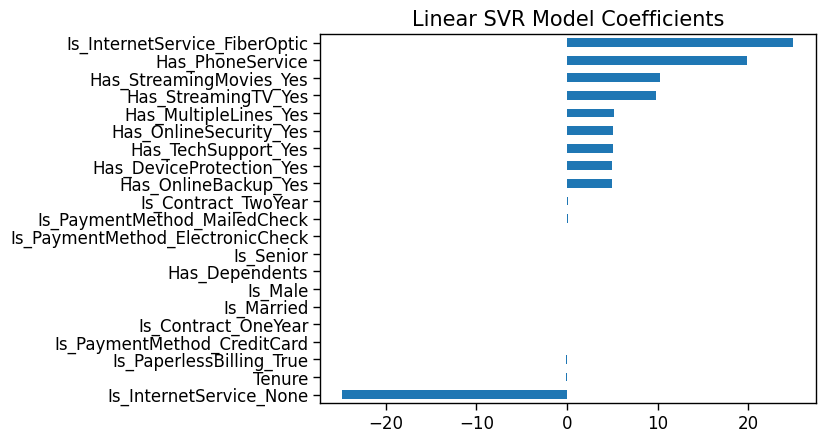

In [31]:
# SVM Regression ------------------------------------------------------------
svr = SVR(kernel='linear', C=1.0) # Linear kernel matches Lineear Regression
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)
#
print('Model coefficients:', svr.coef_)
#extract the coefficients
#coef = pd.DataFrame({"var": X_train.columns,"coef":svr.coef_})

coef = pd.Series(svr.coef_.flatten(), X_train.columns).sort_values()
coef.plot(kind='barh', title='Linear SVR Model Coefficients')
plt.show()



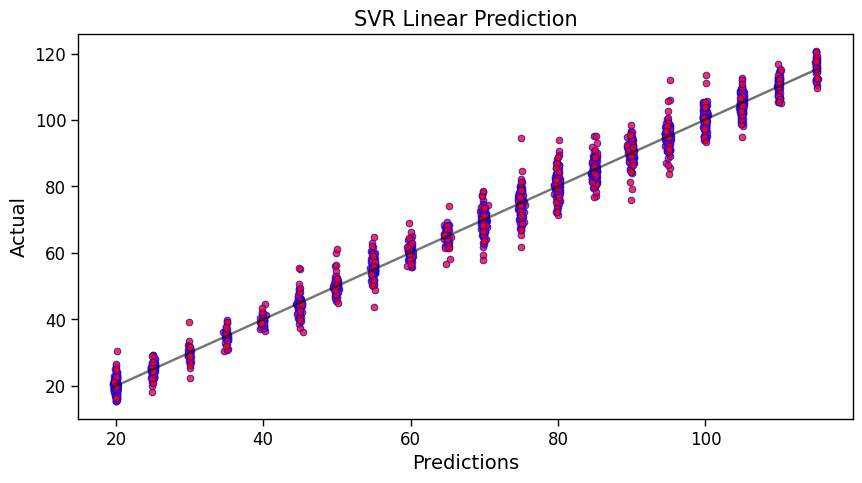

In [32]:
# Visualising the results in a regplot between y_pred and y_test.
# Pass as additional arguments
# scatter_kws={'color':'red','edgecolor':'blue', 'linewidths':0.7}
# and line_kws={'color':'black','alpha':0.5}
svr = SVR(kernel='linear', C=1.0) # Linear kernel matches Lineear Regression
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)
#
plt.figure(figsize=(10,5))
sns.regplot(x= y_pred, y = y_test,
            scatter_kws={'color':'red',
                         'edgecolor':'blue',
                         'linewidths':0.7},
            line_kws={'color':'black','alpha':0.5}
           )
plt.xlabel('Predictions')
plt.ylabel('Actual')
plt.title("SVR Linear Prediction")
plt.show()

##Importances for XGRegressor


In [33]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

### Importances

/tmp/ipykernel_127556/3472171243.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(feature_scores.index, size = 10)


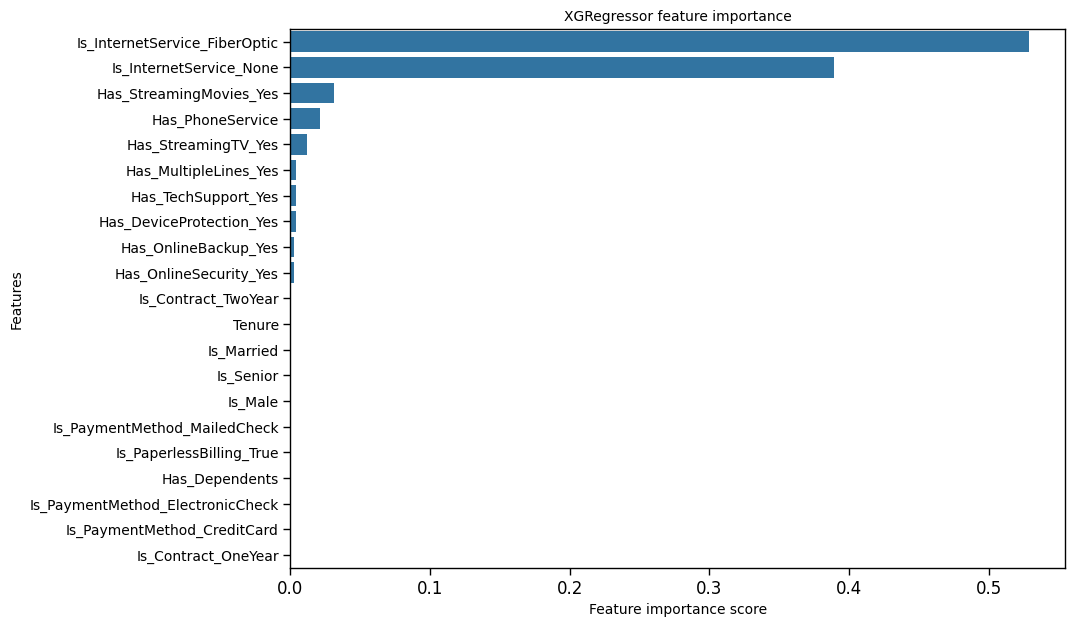

In [34]:
# Get the feature importance from the rf classifier using rf_opt.feature_importances_
# Cast it into a pd.DataFrame and use sort_values to sort by the importance

feature_scores = pd.DataFrame(xgb.feature_importances_, index=X_train.columns, columns=['Importance'])
feature_scores.sort_values(by='Importance', ascending=False, inplace=True)
#feature_scores.head(10)
#
# Plot the rf_opt.feature_importances_ in a barplot

f, ax = plt.subplots(figsize=(10, 7))
ax = sns.barplot(x='Importance', y=feature_scores.index, data=feature_scores)
ax.set_title("XGRegressor feature importance", size = 10)
ax.set_yticklabels(feature_scores.index, size = 10)
ax.set_xlabel("Feature importance score", size = 10)
ax.set_ylabel("Features", size = 10)
plt.show()

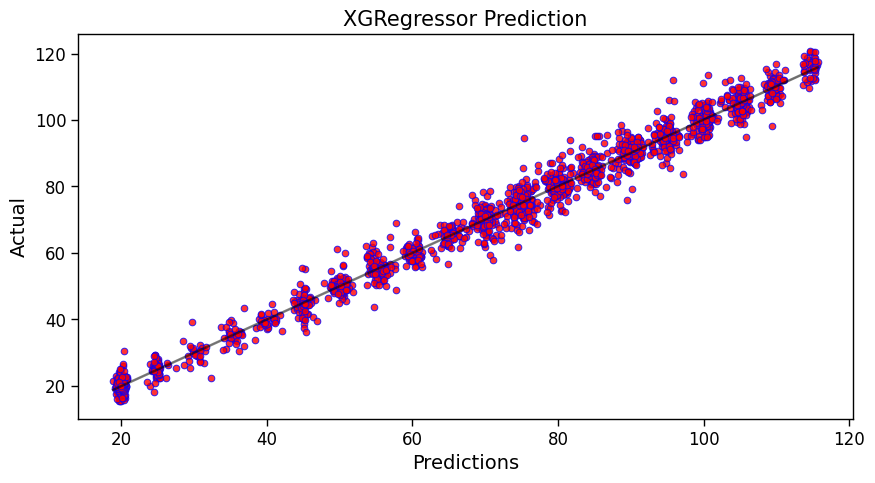

In [35]:
# Pass as additional arguments
# scatter_kws={'color':'red','edgecolor':'blue', 'linewidths':0.7}
# and line_kws={'color':'black','alpha':0.5}

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
#
plt.figure(figsize=(10,5))
sns.regplot(x= y_pred, y = y_test,
            scatter_kws={'color':'red',
                         'edgecolor':'blue',
                         'linewidths':0.7},
            line_kws={'color':'black','alpha':0.5}
           )
plt.xlabel('Predictions')
plt.ylabel('Actual')
plt.title("XGRegressor Prediction")
plt.show()

### SVR Non Linear Importances with Shapley

In [36]:
# SVM Regression ------------------------------------------------------------
svr = SVR()
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)


In [37]:
#Select a random sample of 50-100 rows from training as background
#background_sample = X_train.sample(100, random_state=42)

# Initialize the Explainer with the raw data sample
# We pass the .predict function of our SVR model
#explainer = shap.KernelExplainer(svr.predict, background_sample)

# Calculate SHAP values for the first 50 rows of test data
# Increasing this number will make the plot more accurate but much slower
#shap_values = explainer.shap_values(X_test.iloc[:50, :])

# DGenerate the Summary Plot
#plt.figure(figsize=(10, 6))
#shap.summary_plot(shap_values, X_test.iloc[:50, :])

#Second Approach: Feature Engineering

In [38]:
#read again the dataset
url = "https://github.com/kitlapp/Telco_ML/raw/main/ml_ready_dataset_nodummies.parquet"
df = pd.read_parquet(url, engine="pyarrow")

In [39]:
df.shape

(7043, 20)

## Engineered Features

In [40]:
#Inspired by the Titanic Dataset we can what driver a family can be
# np.select to create a categorical label based on multiple conditions
conditions = [
    (df['Is_Married'] == True) & (df['Has_Dependents'] == True),  # Family
    (df['Is_Married'] == True) & (df['Has_Dependents'] == False), # Couple
    (df['Is_Married'] == False) & (df['Has_Dependents'] == True), # Single Parent
    (df['Is_Married'] == False) & (df['Has_Dependents'] == False) # Single Adult
]
choices = ['Family', 'Couple', 'Single Parent', 'Single Adult']

df['Household_Type'] = np.select(conditions, choices, default='Unknown')

In [41]:
#Sanity Check
df.head()

,Is_Male,Is_Senior,Is_Married,Has_Dependents,Tenure,Has_PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,Is_PaperlessBilling,PaymentMethod,Total_Charges,Is_Churned,Avg_Monthly_Charge,Household_Type
0,False,False,True,False,1,False,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,True,Electronic check,29.85,False,29.85,Couple
1,True,False,False,False,34,True,No,DSL,Yes,No,Yes,No,No,No,One year,False,Mailed check,1889.50,False,55.57,Single Adult
2,True,False,False,False,2,True,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,True,Mailed check,108.15,True,54.08,Single Adult
3,True,False,False,False,45,False,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,False,Bank transfer (automatic),1840.75,False,40.91,Single Adult
4,False,False,False,False,2,True,No,Fiber optic,No,No,No,No,No,No,Month-to-month,True,Electronic check,151.65,True,75.82,Single Adult


In [42]:
#We drop the initial columns as the information has passed to the Household Type
df.drop(columns =['Is_Married','Has_Dependents'], inplace = True)

In [43]:
df.shape

(7043, 19)

In [44]:
#Drop Correlated Features and Tenure =0
df.drop(['Total_Charges', 'Is_Churned'], axis=1, inplace=True)
df = df[df['Tenure'] > 0].copy()

## Prepare for the ML Algorithms

In [45]:
#define X and y
y = df['Avg_Monthly_Charge']
X = df.drop('Avg_Monthly_Charge',axis = 1)
print ("X dimensions: ", X.shape)
print ("y dimensions: ", y.shape)

X dimensions:  (7032, 16)
y dimensions:  (7032,)


In [46]:
# Use the train_test_split() function from sklearn. Use 30% of your data for the test set. Use stratification if needed.
# Set random_state=42 (for reproducibility). Print the dimensionality (shape) of X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.30,
                                                    random_state=42)

print('Shape of X_train and y_train: ', X_train.shape, y_train.shape)
print('Shape of X_test and y_test: ',   X_test.shape,  y_test.shape)

Shape of X_train and y_train:  (4922, 16) (4922,)
Shape of X_test and y_test:  (2110, 16) (2110,)


In [47]:
#Code provided fromteh lectures
#
# Instead of 6 columns being with "No Internet" flags, we just use the main InternetService category
categorical_features = X_train.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()

cat_steps = [('OHE', OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False))]
pipe_cat = Pipeline(cat_steps)
num_steps = [('scaler', StandardScaler())]
pipe_num = Pipeline(num_steps)

one_pipe = ColumnTransformer(
    transformers=[
        ('numbers', pipe_num, numeric_features),
        ('categories',pipe_cat,categorical_features)
    ])

In [48]:
#fit and transform the train data set. transform the test
X_train_ohe = one_pipe.fit_transform(X_train)
X_test_ohe = one_pipe.transform(X_test)

In [49]:
X_train_ohe.head()

,numbers__Tenure,categories__Is_Male_True,categories__Is_Senior_True,categories__Has_PhoneService_True,categories__MultipleLines_No phone service,categories__MultipleLines_Yes,categories__InternetService_Fiber optic,categories__InternetService_No,categories__OnlineSecurity_No internet service,categories__OnlineSecurity_Yes,categories__OnlineBackup_No internet service,categories__OnlineBackup_Yes,categories__DeviceProtection_No internet service,categories__DeviceProtection_Yes,categories__TechSupport_No internet service,categories__TechSupport_Yes,categories__StreamingTV_No internet service,categories__StreamingTV_Yes,categories__StreamingMovies_No internet service,categories__StreamingMovies_Yes,categories__Contract_One year,categories__Contract_Two year,categories__Is_PaperlessBilling_True,categories__PaymentMethod_Credit card (automatic),categories__PaymentMethod_Electronic check,categories__PaymentMethod_Mailed check,categories__Household_Type_Family,categories__Household_Type_Single Adult,categories__Household_Type_Single Parent
3946,-0.952316,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3394,-0.262207,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1635,-1.195884,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4088,-1.033505,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1886,1.402172,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [50]:
# We need to clean the column names after Column Transformation to make them more easily readable
X_train_ohe.columns = (X_train_ohe.columns
                       .str.replace('numbers__', '', regex=False)
                       .str.replace('categories__', '', regex=False))

#Same for the X_test_ohe
X_test_ohe.columns = (X_test_ohe.columns
                      .str.replace('numbers__', '', regex=False)
                      .str.replace('categories__', '', regex=False))

# Check the results
X_train_ohe.head()

,Tenure,Is_Male_True,Is_Senior_True,Has_PhoneService_True,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,Is_PaperlessBilling_True,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Household_Type_Family,Household_Type_Single Adult,Household_Type_Single Parent
3946,-0.952316,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3394,-0.262207,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1635,-1.195884,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4088,-1.033505,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1886,1.402172,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [51]:
mapping = {
     'Is_Male_True': 'Is_Male',
     'Is_Senior_True': 'Is_Senior',
    # 'Is_Married_True': 'Is_Married',
    # 'Has_Dependents_True': 'Has_Dependents',
     'Has_PhoneService_True': 'Has_PhoneService',
     # One-hot / multi-category features
    'OnlineSecurity_Yes': 'Has_OnlineSecurity_Yes',
    'OnlineSecurity_No internet service': 'Has_OnlineSecurity_NoInternet',
    #'OnlineSecurity_Yes': 'Has_OnlineSecurity_Yes',

    #'OnlineBackup_No': 'Has_OnlineBackup_No',
    'OnlineBackup_No internet service': 'Has_OnlineBackup_NoInternet',
    'OnlineBackup_Yes': 'Has_OnlineBackup_Yes',

    #'DeviceProtection_No': 'Has_DeviceProtection_No',
    'DeviceProtection_No internet service': 'Has_DeviceProtection_NoInternet',
    'DeviceProtection_Yes': 'Has_DeviceProtection_Yes',

    #'TechSupport_No': 'Has_TechSupport_No',
    'TechSupport_No internet service': 'Has_TechSupport_NoInternet',
    'TechSupport_Yes': 'Has_TechSupport_Yes',

    #'StreamingTV_No': 'Has_StreamingTV_No',
    'StreamingTV_No internet service': 'Has_StreamingTV_NoInternet',
    'StreamingTV_Yes': 'Has_StreamingTV_Yes',

    #'StreamingMovies_No': 'Has_StreamingMovies_No',
    'StreamingMovies_No internet service': 'Has_StreamingMovies_NoInternet',
    'StreamingMovies_Yes': 'Has_StreamingMovies_Yes',

    #'MultipleLines_No': 'Has_MultipleLines_No',
    'MultipleLines_No phone service': 'Has_MultipleLines_NoPhone',
    'MultipleLines_Yes': 'Has_MultipleLines_Yes',

    #'InternetService_DSL': 'Is_InternetService_DSL',
    'InternetService_Fiber optic': 'Is_InternetService_FiberOptic',
    'InternetService_No': 'Is_InternetService_None',

    #'Contract_Month-to-month': 'Is_Contract_MonthToMonth',
    'Contract_One year': 'Is_Contract_OneYear',
    'Contract_Two year': 'Is_Contract_TwoYear',

    #'PaymentMethod_Bank transfer (automatic)': 'Is_PaymentMethod_BankTransfer',
    'PaymentMethod_Credit card (automatic)': 'Is_PaymentMethod_CreditCard',
    'PaymentMethod_Electronic check': 'Is_PaymentMethod_ElectronicCheck',
    'PaymentMethod_Mailed check': 'Is_PaymentMethod_MailedCheck'
}
X_train_ohe = X_train_ohe.rename(columns=mapping)
X_test_ohe = X_test_ohe.rename(columns=mapping)

In [52]:
X_train_ohe.head(2)

,Tenure,Is_Male,Is_Senior,Has_PhoneService,Has_MultipleLines_NoPhone,Has_MultipleLines_Yes,Is_InternetService_FiberOptic,Is_InternetService_None,Has_OnlineSecurity_NoInternet,Has_OnlineSecurity_Yes,Has_OnlineBackup_NoInternet,Has_OnlineBackup_Yes,Has_DeviceProtection_NoInternet,Has_DeviceProtection_Yes,Has_TechSupport_NoInternet,Has_TechSupport_Yes,Has_StreamingTV_NoInternet,Has_StreamingTV_Yes,Has_StreamingMovies_NoInternet,Has_StreamingMovies_Yes,Is_Contract_OneYear,Is_Contract_TwoYear,Is_PaperlessBilling_True,Is_PaymentMethod_CreditCard,Is_PaymentMethod_ElectronicCheck,Is_PaymentMethod_MailedCheck,Household_Type_Family,Household_Type_Single Adult,Household_Type_Single Parent
3946,-0.952316,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3394,-0.262207,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


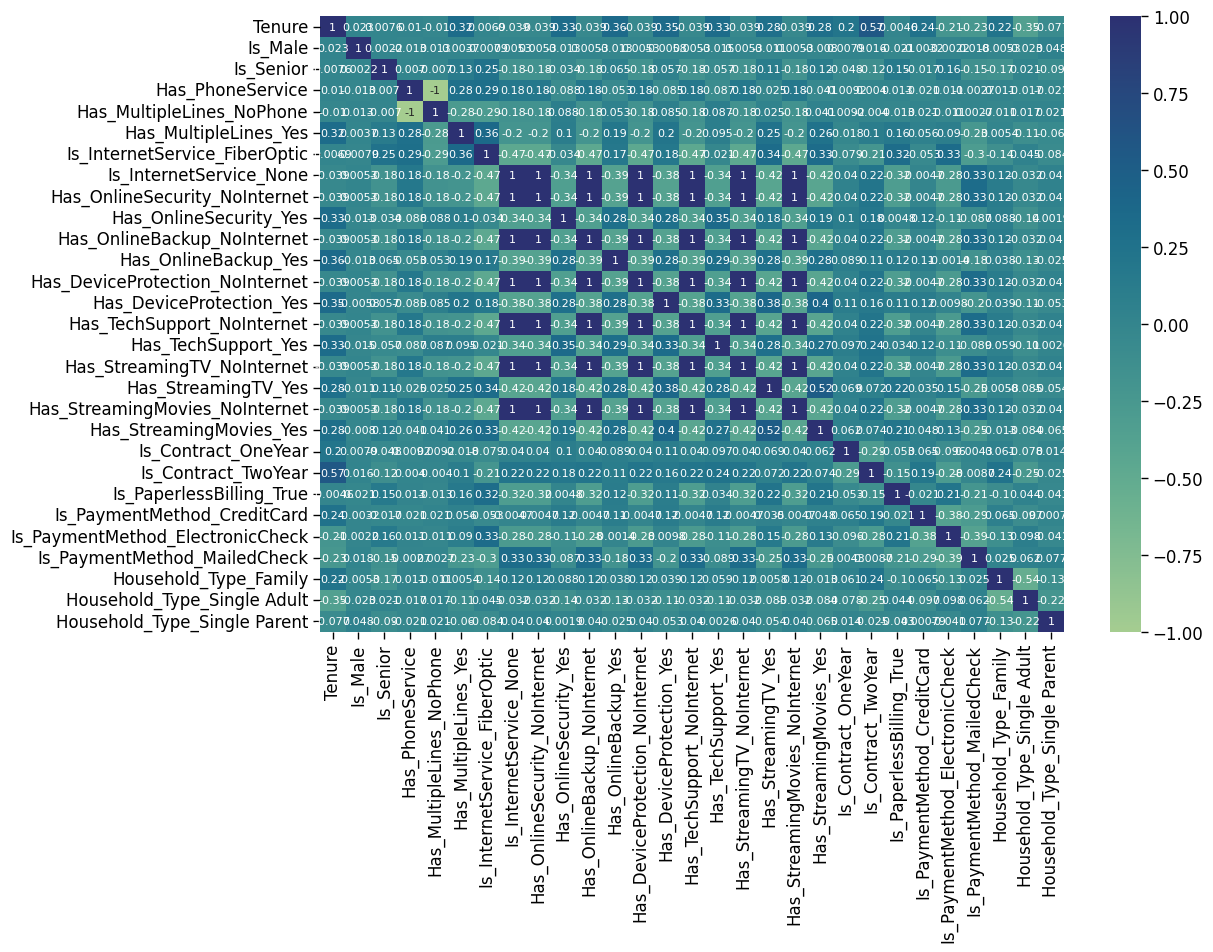

In [53]:
# Calculate the correlation matrix of X_train DataFrame using the .corr() function and
# save it in a variable called 'corr_matrix'. Then pass the corr_matrix to the sns.heatmap() function for plotting.
# Optional: you can use f, ax = plt.subplots(figsize=(12, 8))
# Optional sns.heatmap arguments : annot=True,  annot_kws={'size': 8} and cmap="Spectral_r"

corr_matrix = X_train_ohe.corr()

f, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,
            annot_kws={'size': 8},
            cmap="crest");

In [54]:
#Find the columns to exclude with names "NoIntenet" or "NoPhone" from the list
# Filter the list
alllist = X_train_ohe.columns.to_list()
redundant_terms = ["NoInternet", "NoPhone"]
toclean_list = [item for item in alllist if any(term in item for term in redundant_terms)]
print(toclean_list)


['Has_MultipleLines_NoPhone', 'Has_OnlineSecurity_NoInternet', 'Has_OnlineBackup_NoInternet', 'Has_DeviceProtection_NoInternet', 'Has_TechSupport_NoInternet', 'Has_StreamingTV_NoInternet', 'Has_StreamingMovies_NoInternet']


In [55]:
X_train_ohe = X_train_ohe.drop(columns=toclean_list)
X_test_ohe = X_test_ohe.drop(columns=toclean_list)

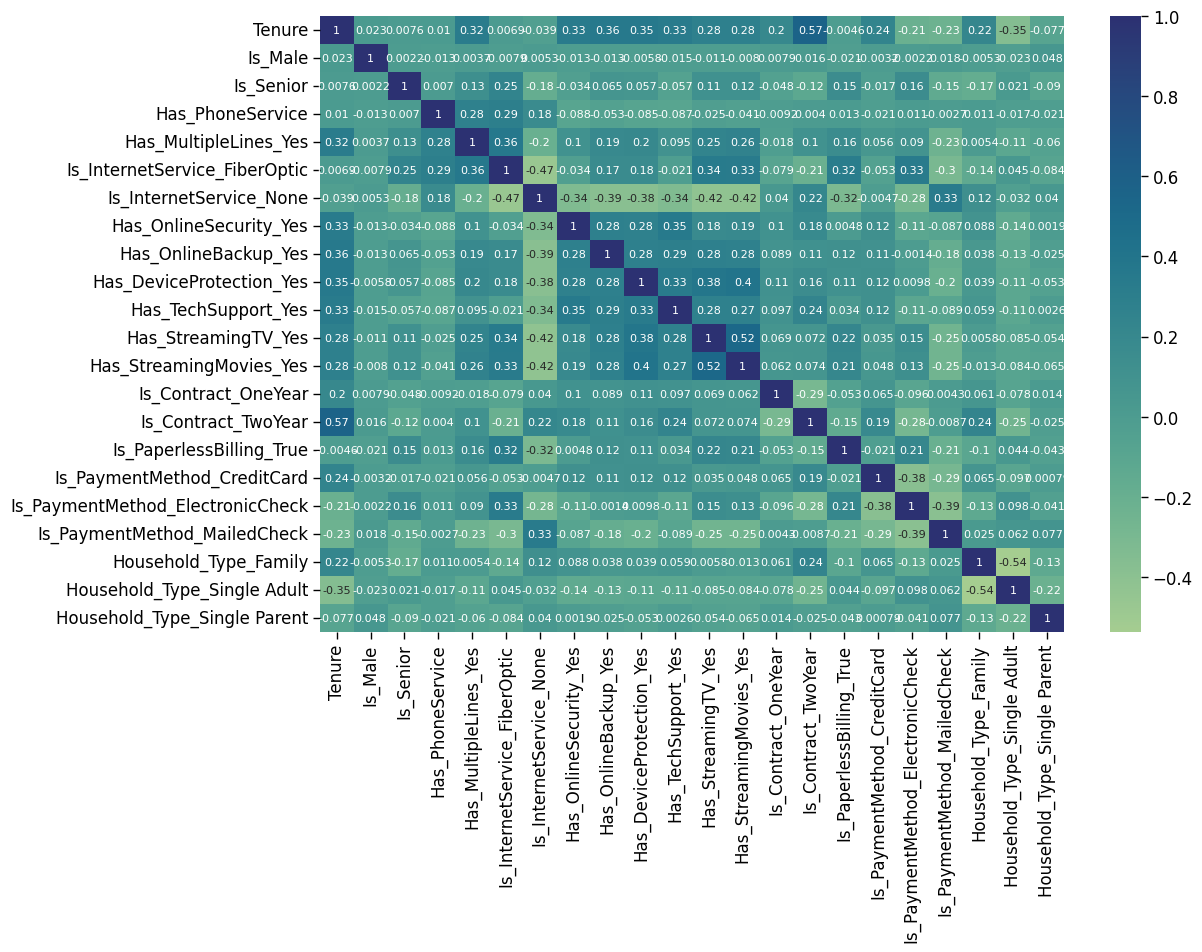

In [56]:
corr_matrix = X_train_ohe.corr()

f, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,
            annot_kws={'size': 8},
            cmap="crest");

## Lasso and XG Regressor

In [57]:
X_train = X_train_ohe.copy()
X_test = X_test_ohe.copy()

In [58]:
#Lasso Regression--------------------------------------------------------------
lassoCV_model = LassoCV(alphas=np.logspace(-6, 6, 13), cv=10, random_state=0)
lassoCV_model.fit(X_train, y_train)
optimal_alpha = lassoCV_model.alpha_
#
lasso_regr = Lasso(alpha = optimal_alpha)
lasso_regr.fit(X_train, y_train)
y_pred = lasso_regr.predict(X_test)
regr_results = pd.concat([regr_results, pd.json_normalize({'Model': 'Lasso & Household',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5),
                                                           'Parameter': round(optimal_alpha,5)})])
# XGBoost Regression ---------------------------------------------------------
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

regr_results = pd.concat([regr_results, pd.json_normalize({
                                                      'Model': 'XGRegressor & Household',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5)})])

In [59]:
regr_results.fillna('--')

,Model,r2,MAE,Parameter
0,Linear Regression,0.99080,2.01877,--
0,Ridge,0.99080,2.01878,0.1
0,Lasso,0.99080,2.01854,0.01
0,RandomForest,0.98807,2.33721,--
0,KNN,0.95690,4.35389,--
0,SVR Linear,0.99081,2.02009,--
0,SVR NonLinear,0.98790,2.41806,--
0,XGRegressor,0.99012,2.12179,--
0,Lasso & Household,0.99080,2.01853,0.01
0,XGRegressor & Household,0.99005,2.12432,--


Model coefficients: [-1.44430169e-02  0.00000000e+00 -2.99067664e-02  1.99705141e+01
  5.07938465e+00  2.48550443e+01 -2.49660747e+01  5.06592412e+00
  4.87184328e+00  4.96861109e+00  5.11518016e+00  9.70251949e+00
  1.02475123e+01 -0.00000000e+00 -0.00000000e+00 -1.54274319e-02
 -0.00000000e+00  4.06805299e-03  0.00000000e+00 -0.00000000e+00
  0.00000000e+00  0.00000000e+00]


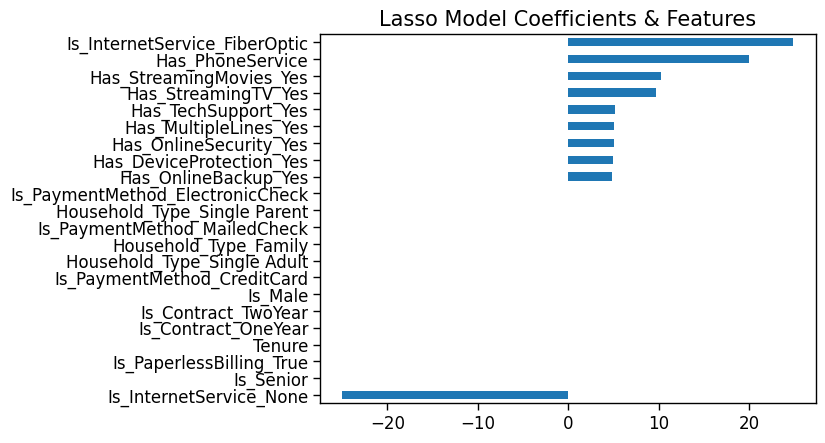

In [60]:
print('Model coefficients:', lasso_regr.coef_)
#extract the coefficients
coef = pd.Series(lasso_regr.coef_, X_train.columns).sort_values()
coef.plot(kind='barh', title='Lasso Model Coefficients & Features')
plt.show()

/tmp/ipykernel_127556/4104227899.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(feature_scores.index, size = 10)


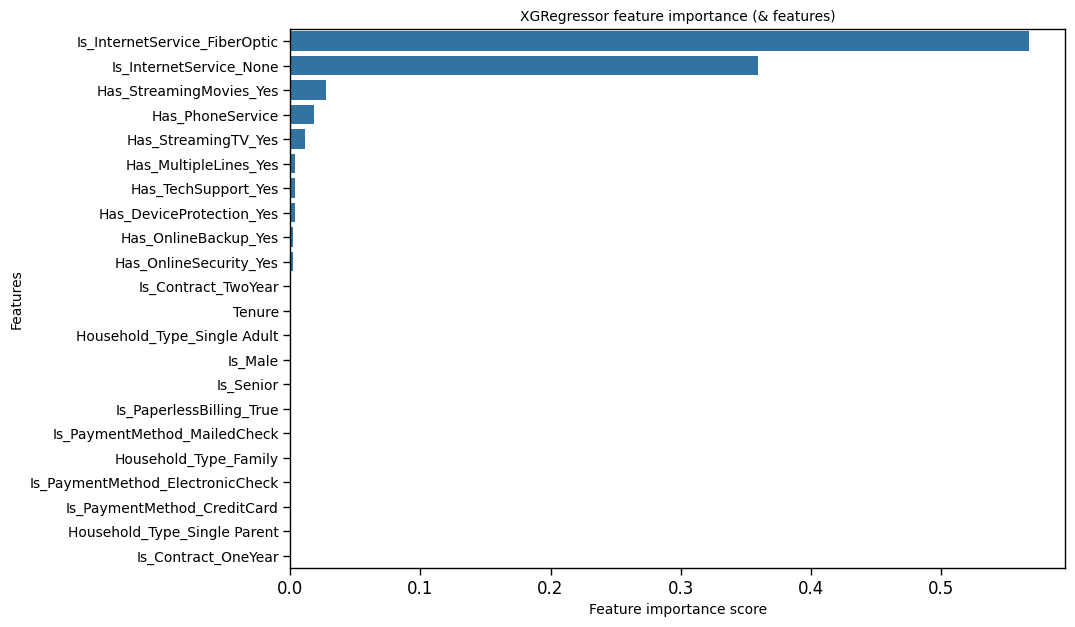

In [61]:
# Get the feature importance from the rf classifier using rf_opt.feature_importances_
# Cast it into a pd.DataFrame and use sort_values to sort by the importance

feature_scores = pd.DataFrame(xgb.feature_importances_, index=X_train.columns, columns=['Importance'])
feature_scores.sort_values(by='Importance', ascending=False, inplace=True)
#feature_scores.head(10)
#
# Plot the rf_opt.feature_importances_ in a barplot

f, ax = plt.subplots(figsize=(10, 7))
ax = sns.barplot(x='Importance', y=feature_scores.index, data=feature_scores)
ax.set_title("XGRegressor feature importance (& features)", size = 10)
ax.set_yticklabels(feature_scores.index, size = 10)
ax.set_xlabel("Feature importance score", size = 10)
ax.set_ylabel("Features", size = 10)
plt.show()

**Conclusion**: it seems that the Household type does not influence the avg_monthly price paid.

##Remove Lasso zero weighted Features

In [62]:
#extract the coefficients
coef_lasso = pd.DataFrame({"var": X_train.columns,
                           "coef":lasso_regr.coef_})
coef_lasso

,var,coef
0,Tenure,-0.014443
1,Is_Male,0.000000
2,Is_Senior,-0.029907
3,Has_PhoneService,19.970514
4,Has_MultipleLines_Yes,5.079385
5,Is_InternetService_FiberOptic,24.855044
6,Is_InternetService_None,-24.966075
7,Has_OnlineSecurity_Yes,5.065924
8,Has_OnlineBackup_Yes,4.871843
9,Has_DeviceProtection_Yes,4.968611


In [63]:
#Important features to keep
features_to_keep = coef_lasso[coef_lasso['coef'] != 0]['var'].tolist()
features_to_keep

['Tenure',
 'Is_Senior',
 'Has_PhoneService',
 'Has_MultipleLines_Yes',
 'Is_InternetService_FiberOptic',
 'Is_InternetService_None',
 'Has_OnlineSecurity_Yes',
 'Has_OnlineBackup_Yes',
 'Has_DeviceProtection_Yes',
 'Has_TechSupport_Yes',
 'Has_StreamingTV_Yes',
 'Has_StreamingMovies_Yes',
 'Is_PaperlessBilling_True',
 'Is_PaymentMethod_ElectronicCheck']

In [64]:
X_train = X_train[features_to_keep]
X_test = X_test[features_to_keep]

In [65]:
#Lasso Regression--------------------------------------------------------------
lassoCV_model = LassoCV(alphas=np.logspace(-6, 6, 13), cv=10, random_state=0)
lassoCV_model.fit(X_train, y_train)
optimal_alpha = lassoCV_model.alpha_
#
lasso_regr = Lasso(alpha = optimal_alpha)
lasso_regr.fit(X_train, y_train)
y_pred = lasso_regr.predict(X_test)
regr_results = pd.concat([regr_results, pd.json_normalize({'Model': 'Lasso & Selected F',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5),
                                                           'Parameter': round(optimal_alpha,5)})])
# XGBoost Regression ---------------------------------------------------------
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

regr_results = pd.concat([regr_results, pd.json_normalize({
                                                      'Model': 'XGRegressor & Selected F',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5)})])

In [66]:
regr_results.fillna('--')

,Model,r2,MAE,Parameter
0,Linear Regression,0.99080,2.01877,--
0,Ridge,0.99080,2.01878,0.1
0,Lasso,0.99080,2.01854,0.01
0,RandomForest,0.98807,2.33721,--
0,KNN,0.95690,4.35389,--
0,SVR Linear,0.99081,2.02009,--
0,SVR NonLinear,0.98790,2.41806,--
0,XGRegressor,0.99012,2.12179,--
0,Lasso & Household,0.99080,2.01853,0.01
0,XGRegressor & Household,0.99005,2.12432,--


 We see that XGRegressor R^2 becomes a bit smaller. Meaning that removing the columns reduces the explained variability, so these columns did add somthing. For XB Regressor the MAE also becomes a bit smaller .
 Also alpha has become much more smaller which means that the weights of the features are important.

Also it is important to note again that Lasso performs better than XGRegression

##Randomized CVGrid

https://xgboost.readthedocs.io/en/stable/parameter.html  
https://www.geeksforgeeks.org/machine-learning/xgboost-for-regression/

**Tree Complexity (Control Overfitting)**  
These parameters dictate how complex each individual tree can get.

**max_depth:**The maximum depth of each tree.  
Default: 6.  
Typical Search: [3, 5, 7, 9]. Lower values prevent overfitting.  
**min_child_weight:** Minimum "weight" (sum of instances) required in a child node.   
Default: 1.  
Typical Search: [1, 3, 5]. Higher values make the model more conservative.  

**gamma (min_split_loss):** The minimum loss reduction required to make a further split.
Default: 0.
Typical Search: [0, 0.1, 0.2]. Acts as a "pseudo-pruning" tool.

**Boosting Speed & Volume**  
These control the overall learning process across the entire forest.

**n_estimators:** The total number of trees to build.  
Typical Search: [100, 500, 1000].  

**learning_rate (eta):** How much to "shrink" the contribution of each tree.
Default: 0.3.  
Typical Search: [0.01, 0.05, 0.1]. Crucial: If you lower this, you must increase n_estimators.  

**Randomness (Robustness)**  
These introduce noise to prevent the model from "memorizing" specific rows or columns.   
subsample: Fraction of the training data to sample for each tree.  
Typical Search: [0.6, 0.8, 1.0].  

**colsample_bytree:** Like max_features Fraction of features (columns) to sample for each tree.
Typical Search: [0.6, 0.8, 1.0].

**Regularization (The "Lasso/Ridge" of XGBoost**)  
reg_alpha: L1 regularization (similar to Lasso). It can drive some feature weights to zero.  
reg_lambda: L2 regularization (similar to Ridge). It smooths out the weights.

In [67]:
param_grid = {
    # Tree Complexity
    #'max_depth': [3, 4, 5], #Lower Depth --> ower XAI
    'max_depth': np.arange(1,50,2).tolist(),
    'min_child_weight': [1,3, 5],        # Higher values prevent picking up noise
    'min_split_loss' : [0, 0.1, 0.2],

    # Learning & Volume (Forest Level)
    'n_estimators': np.arange(10, 1000, 50),  # Number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1, 0.3, 0.5], # Shrinkage to prevent overshooting

    # 3. Randomness (Robustness)
    'subsample': [0.6,0.8, 1.0],           # % of rows to use per tree
    'colsample_bytree': [0.6,0.8, 1.0],    # % of features to use per tree

    # 4. Regularization (The "Lasso/Ridge" of XGBoost)
 #   'reg_alpha': [0, 0.1, 1],          # L1 regularization (Lasso-style)
    'reg_lambda': [0, 0.01, 0.1, 1, 5]               # L2 regularization (Ridge-style)
}

param_grid = {'n_estimators': np.arange(10, 300, 10),
              'max_features' : ['sqrt', 'log2', None],
              'max_depth': [None, 3, 5, 10, 20],
             }

###Code for Randomized Grid Search
XGBRegressor_grid_CV = RandomizedSearchCV(XGBRegressor(random_state=42),
                            param_distributions=param_grid,
                            n_iter =30,
                            cv = 10,
                            n_jobs = -1,
                            verbose = 1,
                            random_state=42)

#Fit the grid to X_train and y_train
XGBRegressor_grid_CV.fit(X_train, y_train)

In [68]:
#From GEMINI
#Load the pickle model from Github
# 1. Use the 'raw' URL from your GitHub
url = 'https://github.com/kitlapp/Telco_ML/raw/main/tuned_xgboost_model.pkl'

# 2. Download the content
response = requests.get(url)

# 3. Check if the download was successful
if response.status_code == 200:
    # Use BytesIO to turn the downloaded bits into a "file" that joblib can read
    xgb_opt = joblib.load(io.BytesIO(response.content))
    print("Successfully loaded the Tuned XGBoost model from GitHub!")
else:
    print(f"Failed to download. Status code: {response.status_code}")

Successfully loaded the Tuned XGBoost model from GitHub!


In [69]:
# Report the optimal parameters using best_params_
#xgb_opt = XGBRegressor_grid_CV.best_estimator_
xgb_opt.fit(X_train, y_train)
y_pred = xgb_opt.predict(X_test)
regr_results = pd.concat([regr_results, pd.json_normalize({'Model': 'XGRegressor Optimized',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5)})])

In [70]:
#Dump the best model since it is difficult to reproduce it
#joblib.dump(xgb_opt, 'tuned_xgboost_model.pkl')

Best Parameters using grid search:  
  {'subsample': 0.6, 'reg_lambda': 5, 'n_estimators': np.int64(760), 'min_split_loss': 0.1, 'min_child_weight': 5, 'max_depth': 1, 'learning_rate': 0.1, 'colsample_bytree': 0.6}

In [71]:
regr_results

,Model,r2,MAE,Parameter
0,Linear Regression,0.99080,2.01877,NaN
0,Ridge,0.99080,2.01878,0.100
0,Lasso,0.99080,2.01854,0.010
0,RandomForest,0.98807,2.33721,NaN
0,KNN,0.95690,4.35389,NaN
0,SVR Linear,0.99081,2.02009,NaN
0,SVR NonLinear,0.98790,2.41806,NaN
0,XGRegressor,0.99012,2.12179,NaN
0,Lasso & Household,0.99080,2.01853,0.010
0,XGRegressor & Household,0.99005,2.12432,NaN


## SHAP

### LASSO

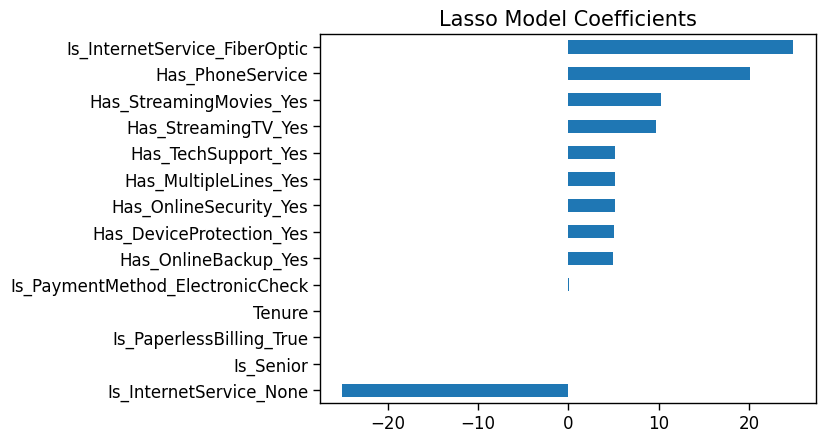

In [73]:
#Coefficients
coef = pd.Series(lasso_regr.coef_, X_train.columns).sort_values()
coef.plot(kind='barh', title='Lasso Model Coefficients')
plt.show()

In [75]:
coef_lasso = pd.DataFrame({"var": X_train.columns,
                           "coef":lasso_regr.coef_}).sort_values(by='coef', ascending=False)
coef_lasso

,var,coef
4,Is_InternetService_FiberOptic,24.855684
2,Has_PhoneService,20.084929
11,Has_StreamingMovies_Yes,10.267576
10,Has_StreamingTV_Yes,9.721340
9,Has_TechSupport_Yes,5.142470
3,Has_MultipleLines_Yes,5.104230
6,Has_OnlineSecurity_Yes,5.101606
8,Has_DeviceProtection_Yes,4.995778
7,Has_OnlineBackup_Yes,4.906129
13,Is_PaymentMethod_ElectronicCheck,0.045292


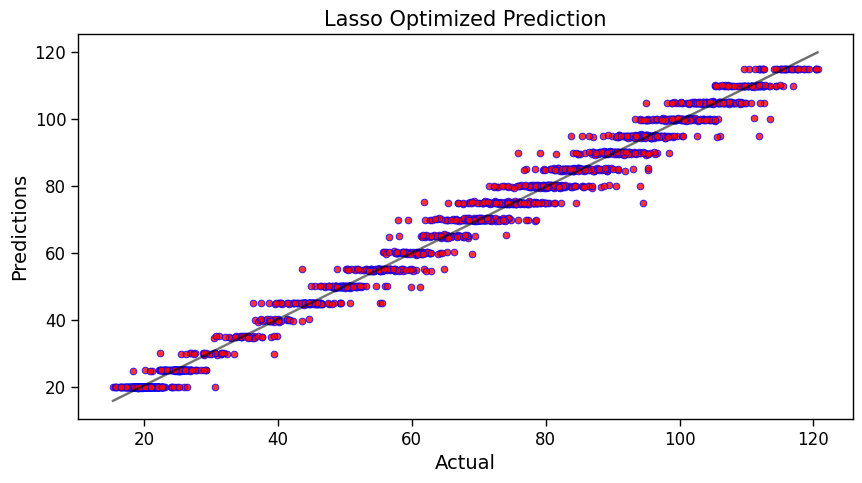

In [93]:
# Visualising the results in a regplot between y_pred and y_test.
# Pass as additional arguments
# scatter_kws={'color':'red','edgecolor':'blue', 'linewidths':0.7}
# and line_kws={'color':'black','alpha':0.5}
#Lasso Regression--------------------------------------------------------------
lassoCV_model = LassoCV(alphas=np.logspace(-6, 6, 13), cv=10, random_state=0)
lassoCV_model.fit(X_train, y_train)
optimal_alpha = lassoCV_model.alpha_
#
lasso_regr = Lasso(alpha = optimal_alpha)
lasso_regr.fit(X_train, y_train)
y_pred_lasso = lasso_regr.predict(X_test)

plt.figure(figsize=(10,5))
sns.regplot(y= y_pred_lasso, x = y_test,
            scatter_kws={'color':'red',
                         'edgecolor':'blue',
                         'linewidths':0.7},
            line_kws={'color':'black','alpha':0.5}
           )
plt.ylabel('Predictions')
plt.xlabel('Actual')
plt.title("Lasso Optimized Prediction")
plt.show()

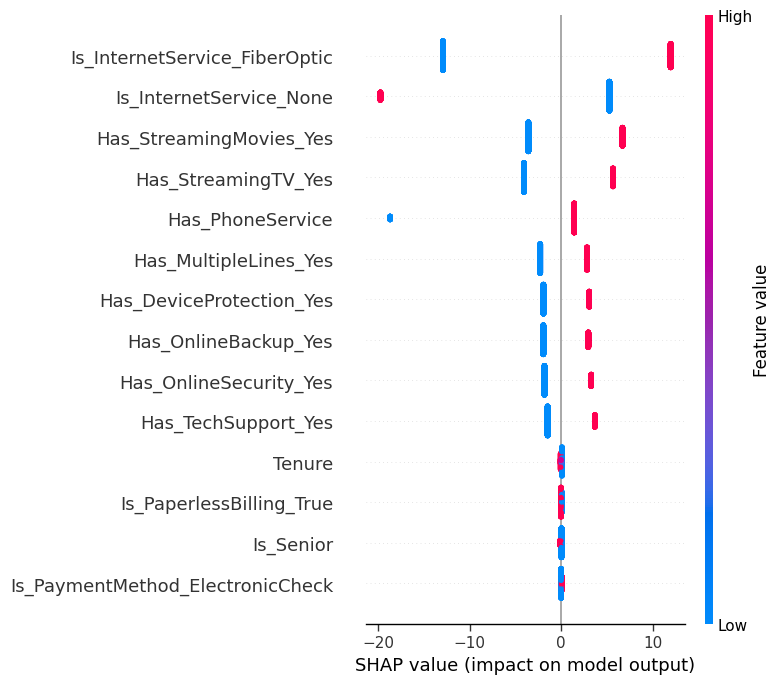

In [77]:
#Visualize information through SHAP - Use Linear Explainer

explainer_lasso = shap.LinearExplainer(lasso_regr, X_train)

# Calculate the SHAP values for the test set
# This calculates how much each feature contributed to each individual prediction
shap_values_lasso = explainer_lasso.shap_values(X_test)

#Create a Beeswarm Plot
# global feature impact
shap.summary_plot(shap_values_lasso, X_test)

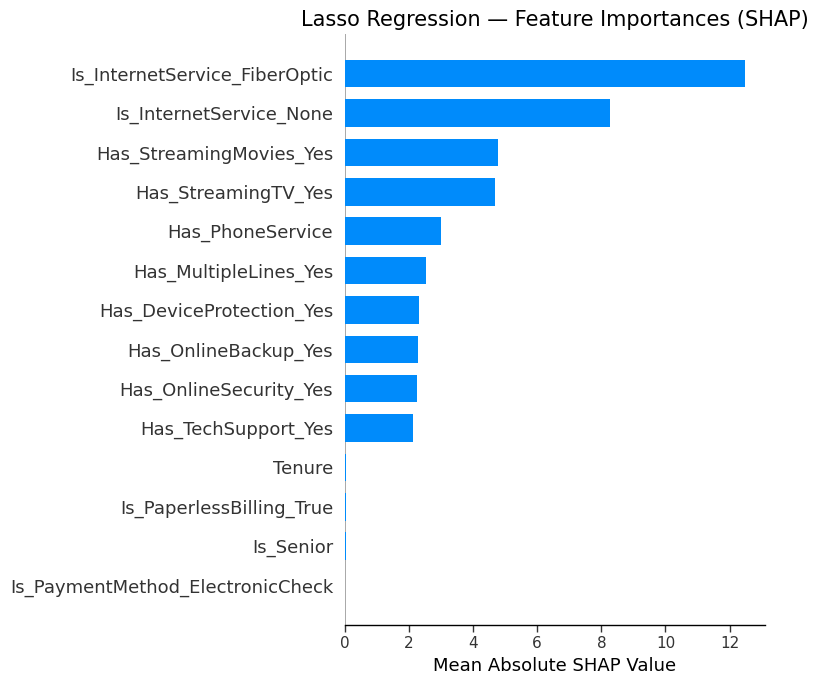

In [80]:
shap.summary_plot(shap_values_lasso, X_test, plot_type="bar", show = False)
plt.title("Lasso Regression — Feature Importances (SHAP)")
plt.xlabel("Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()

### XGBRegressor

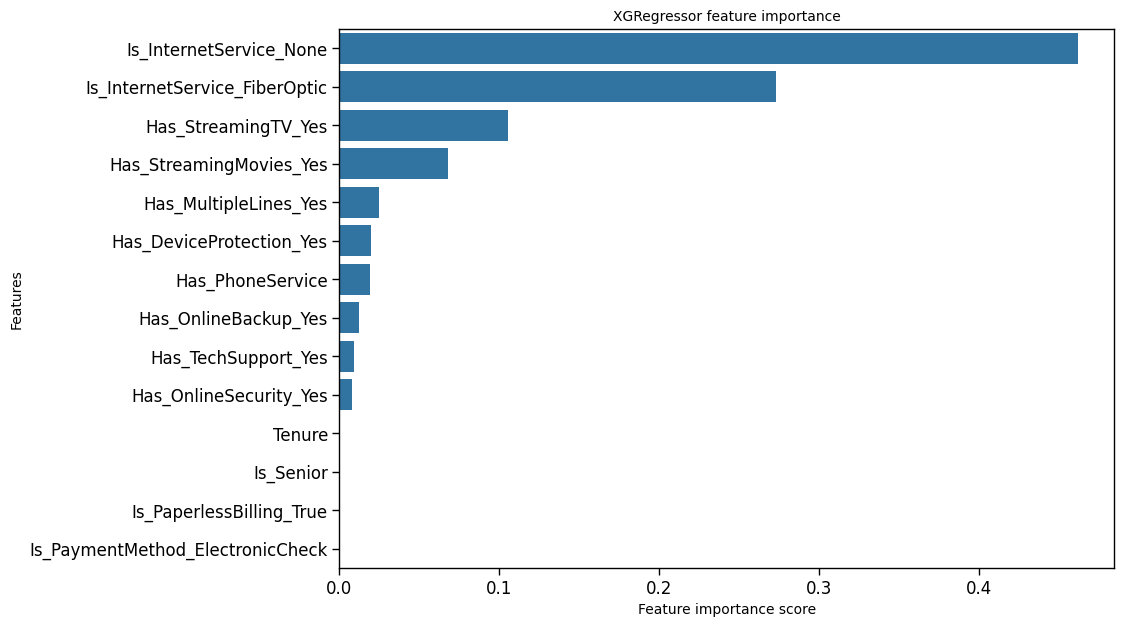

In [82]:
#Tree like model which has feature importances
#You cannot see the direction + or - like with the weights in linear models
#
feature_scores = pd.DataFrame(xgb_opt.feature_importances_, index=X_train.columns, columns=['Importance'])
feature_scores.sort_values(by='Importance', ascending=False, inplace=True)
#feature_scores.head(10)
#
# Plot the rf_opt.feature_importances_ in a barplot

f, ax = plt.subplots(figsize=(10, 7))
ax = sns.barplot(x='Importance', y=feature_scores.index, data=feature_scores)
ax.set_title("XGBRegressor feature importance", size = 10)
#ax.set_yticklabels(feature_scores.index, size = 10)
ax.set_xlabel("Feature importance score", size = 10)
ax.set_ylabel("Features", size = 10)
plt.show()

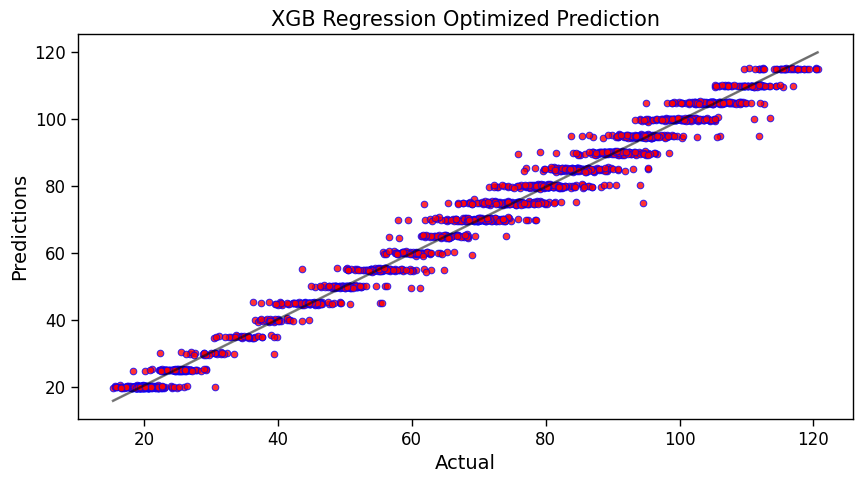

In [94]:
# Visualising the results in a regplot between y_pred and y_test.
# Pass as additional arguments
# scatter_kws={'color':'red','edgecolor':'blue', 'linewidths':0.7}
# and line_kws={'color':'black','alpha':0.5}
#
y_pred_xgb = xgb_opt.predict(X_test)

plt.figure(figsize=(10,5))
sns.regplot(y= y_pred_xgb, x = y_test,
            scatter_kws={'color':'red',
                         'edgecolor':'blue',
                         'linewidths':0.7},
            line_kws={'color':'black','alpha':0.5}
           )
plt.ylabel('Predictions')
plt.xlabel('Actual')
plt.title("XGB Regression Optimized Prediction")
plt.show()

In [83]:
coef_xgb = pd.DataFrame({"var": X_train.columns,
                           "coef":xgb_opt.feature_importances_}).sort_values(by='coef', ascending=False)
coef_xgb

,var,coef
5,Is_InternetService_None,0.461382
4,Is_InternetService_FiberOptic,0.272663
10,Has_StreamingTV_Yes,0.105372
11,Has_StreamingMovies_Yes,0.067940
3,Has_MultipleLines_Yes,0.024991
8,Has_DeviceProtection_Yes,0.019697
2,Has_PhoneService,0.019177
7,Has_OnlineBackup_Yes,0.012187
9,Has_TechSupport_Yes,0.008788
6,Has_OnlineSecurity_Yes,0.007652


Use Tree Explainer for XGBRegressor

In [87]:
# Use Tree Explainer for XGB Tree type model. Encaptulates GINI.
explainer_xgb = shap.TreeExplainer(xgb_opt)

# Calculate SHAP values for the test set
# We use .iloc[:500] to get a sample size for the beeswarm
shap_values_xgb = explainer_xgb(X_test.iloc[:500, :])

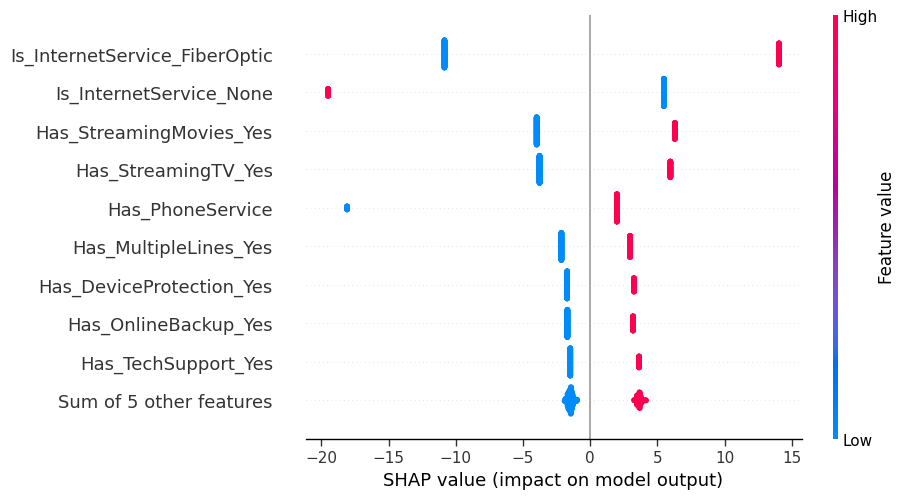

In [88]:
# Create the Beeswarm Plot
shap.plots.beeswarm(shap_values_xgb)

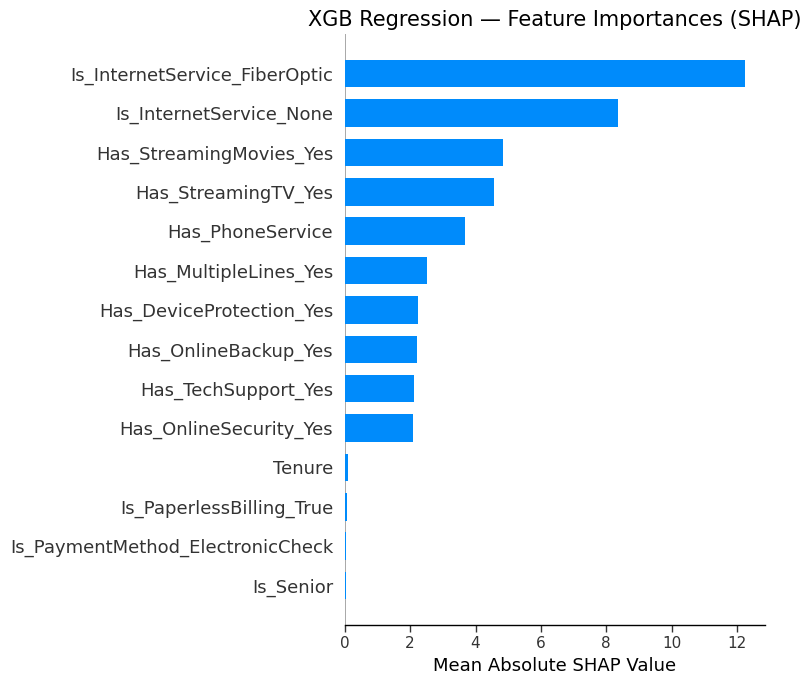

In [89]:
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar", show = False)
plt.title("XGB Regression — Feature Importances (SHAP)")
plt.xlabel("Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()

In [ ]:
#Tree like model which has feature importances
#You cannot see the direction + or - like with the weights in linear models
feature_scores = pd.DataFrame(xgb_opt.feature_importances_, index=X_train.columns, columns=['Importance'])
feature_scores.sort_values(by='Importance', ascending=False, inplace=True)
#feature_scores.head(10)
#
# Plot the rf_opt.feature_importances_ in a barplot

f, ax = plt.subplots(figsize=(10, 7))
ax = sns.barplot(x='Importance', y=feature_scores.index, data=feature_scores)
ax.set_title("XGBRegressor feature importance", size = 10)
#ax.set_yticklabels(feature_scores.index, size = 10)
ax.set_xlabel("Feature importance score", size = 10)
ax.set_ylabel("Features", size = 10)
plt.show()